In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [11]:
base_dir = Path("../../data/classification_results")

In [12]:
def load_summary_tables(base_dir):
    rows = []
    for strategy in ["train_test_split", "nested_cv"]:
        for csv_path in (base_dir / strategy).glob("*/*/summary_across_seeds.csv"):
            classifier = csv_path.parents[1].name
            model_name = csv_path.parents[0].name

            df = pd.read_csv(csv_path)

            for _,row in df.iterrows():
                scope = row["scope"]
                if strategy == "nested_cv":
                    scope = {
                        "inner_train": "train",
                        "inner_validation": "validation",
                        "outer_test": "test"
                    }.get(scope, scope)
                rows.append({
                    "evaluation_strategy": strategy,
                    "classifier": classifier,
                    "model_name": model_name,
                    "scope": scope,
                    "metric": row["metric"],
                    "median": row["median"],
                    "mean": row["mean"],
                    "std": row["std"], 
                    "min": row["min"],
                    "max": row["max"],
                })
    return pd.DataFrame(rows)

In [13]:
summary_df = load_summary_tables(base_dir)

In [14]:
display(summary_df.head())

,evaluation_strategy,classifier,model_name,scope,metric,median,mean,std,min,max
0,train_test_split,linear_svm,mofa_trained_lg2,train,balanced_accuracy,0.713844,0.716409,0.019502,0.671124,0.764419
1,train_test_split,linear_svm,mofa_trained_lg2,train,precision,0.435959,0.440796,0.053433,0.348029,0.530590
2,train_test_split,linear_svm,mofa_trained_lg2,train,recall,0.585380,0.591501,0.038984,0.522807,0.664327
3,train_test_split,linear_svm,mofa_trained_lg2,train,f1,0.492542,0.497567,0.034893,0.424432,0.574253
4,train_test_split,linear_svm,mofa_trained_lg2,train,pr_auc,0.608718,0.615059,0.037292,0.548011,0.703869


Train/Validation/Test of each classifier results

In [15]:
summary_df.shape

(240, 10)

Nested CV only, test scope, primary_metric = PR-AUC

In [16]:
metric_labels = {
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "pr_auc": "PR AUC",
}

model_order = [
    "mofa_trained_lg2",
    "mofa_trained_vsn",
    "mofa_trained_lg2_fs",
    "mofa_trained_vsn_fs",
]

classifier_palette = {
    "linear_svm": "#4C72B0",
    "random_forest": "#DD8452"
}

scope_palette = {
    "train": "#4C72B0",
    "validation": "#DD8452",
    "test": "#55A868"
}

strategy_palette = {
    "train_test_split": "#4C72B0",
    "nested_cv": "#DD8452"
}

In [17]:
nested_test_df = summary_df[
    (summary_df["evaluation_strategy"] == "nested_cv") &
    (summary_df["scope"] == "test")
].copy()

In [18]:
nested_test_pr_auc = nested_test_df[
    nested_test_df["metric"] == "pr_auc"
].sort_values(["mean", "std"], ascending=[False, True])
display(nested_test_pr_auc)

,evaluation_strategy,classifier,model_name,scope,metric,median,mean,std,min,max
149,nested_cv,linear_svm,mofa_trained_lg2_fs,test,pr_auc,0.547527,0.543221,0.045666,0.458935,0.654961
179,nested_cv,linear_svm,mofa_trained_vsn_fs,test,pr_auc,0.543568,0.542663,0.036833,0.474730,0.629187
164,nested_cv,linear_svm,mofa_trained_vsn,test,pr_auc,0.525365,0.530679,0.039297,0.455193,0.590437
134,nested_cv,linear_svm,mofa_trained_lg2,test,pr_auc,0.521610,0.520324,0.032609,0.460592,0.571640
224,nested_cv,random_forest,mofa_trained_vsn,test,pr_auc,0.502841,0.500881,0.026295,0.442766,0.558413
194,nested_cv,random_forest,mofa_trained_lg2,test,pr_auc,0.504319,0.499946,0.028722,0.451623,0.566997
239,nested_cv,random_forest,mofa_trained_vsn_fs,test,pr_auc,0.486851,0.483484,0.033875,0.413296,0.540313
209,nested_cv,random_forest,mofa_trained_lg2_fs,test,pr_auc,0.452492,0.454279,0.038432,0.389655,0.559306


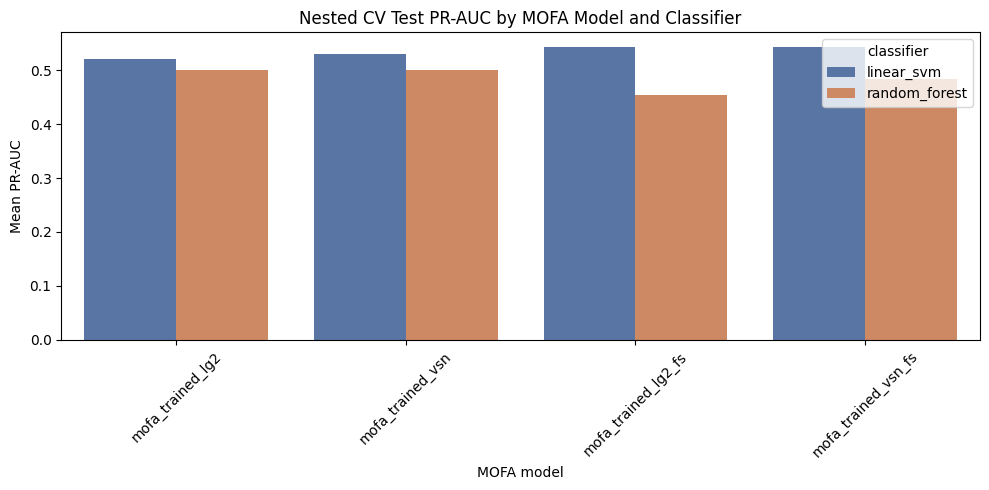

In [19]:
plt.figure(figsize=(10, 5))
plot_df = nested_test_pr_auc.copy()

sns.barplot(
    data=plot_df,
    x="model_name",
    y="mean",
    hue="classifier",
    palette=classifier_palette,
    order=model_order
)

plt.title("Nested CV Test PR-AUC by MOFA Model and Classifier")
plt.xlabel("MOFA model")
plt.ylabel("Mean PR-AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Nested CV only, test scope, primary_metric = F1

In [20]:
nested_test_f1 = nested_test_df[
    nested_test_df["metric"] == "f1"
].sort_values(["mean", "std"], ascending=[False, True])
display(nested_test_f1)

,evaluation_strategy,classifier,model_name,scope,metric,median,mean,std,min,max
193,nested_cv,random_forest,mofa_trained_lg2,test,f1,0.447749,0.455722,0.036967,0.373968,0.524444
178,nested_cv,linear_svm,mofa_trained_vsn_fs,test,f1,0.430860,0.431348,0.036180,0.365885,0.500952
148,nested_cv,linear_svm,mofa_trained_lg2_fs,test,f1,0.420696,0.421767,0.044244,0.319874,0.502123
223,nested_cv,random_forest,mofa_trained_vsn,test,f1,0.420808,0.417975,0.039919,0.322178,0.476667
133,nested_cv,linear_svm,mofa_trained_lg2,test,f1,0.408648,0.407993,0.040395,0.330868,0.494872
163,nested_cv,linear_svm,mofa_trained_vsn,test,f1,0.403364,0.406441,0.034573,0.347210,0.483983
238,nested_cv,random_forest,mofa_trained_vsn_fs,test,f1,0.379383,0.374099,0.039323,0.267599,0.438889
208,nested_cv,random_forest,mofa_trained_lg2_fs,test,f1,0.376180,0.363995,0.043136,0.228030,0.433260


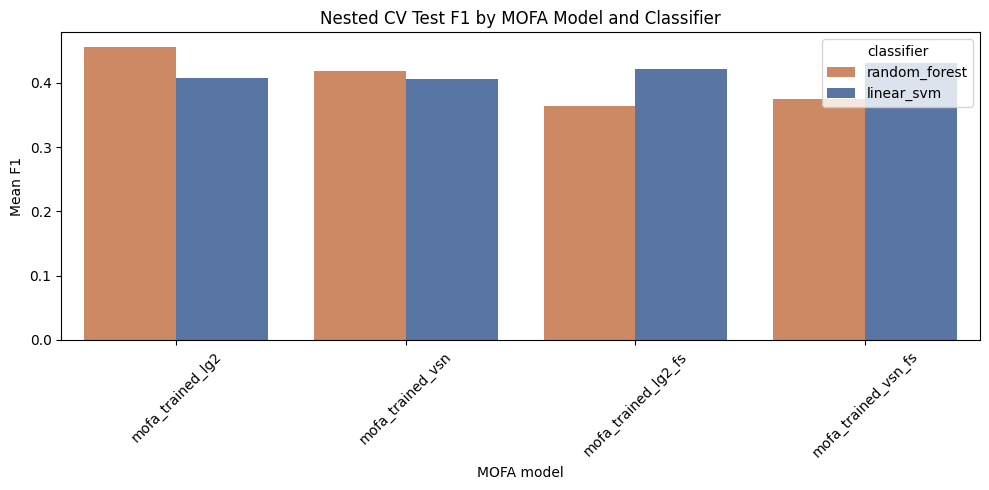

In [21]:
plt.figure(figsize=(10, 5))
plot_df = nested_test_f1.copy()

sns.barplot(
    data=plot_df,
    x="model_name",
    y="mean",
    hue="classifier",
    palette=classifier_palette,
    order=model_order
)

plt.title("Nested CV Test F1 by MOFA Model and Classifier")
plt.xlabel("MOFA model")
plt.ylabel("Mean F1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
nested_test_balanced_accuracy = nested_test_df[
    nested_test_df["metric"] == "balanced_accuracy"
].sort_values(["mean", "std"], ascending=[False, True])
display(nested_test_balanced_accuracy)

,evaluation_strategy,classifier,model_name,scope,metric,median,mean,std,min,max
175,nested_cv,linear_svm,mofa_trained_vsn_fs,test,balanced_accuracy,0.676437,0.677498,0.026463,0.624713,0.721724
145,nested_cv,linear_svm,mofa_trained_lg2_fs,test,balanced_accuracy,0.674655,0.671211,0.033011,0.597816,0.734483
190,nested_cv,random_forest,mofa_trained_lg2,test,balanced_accuracy,0.666379,0.667716,0.015108,0.635862,0.693103
160,nested_cv,linear_svm,mofa_trained_vsn,test,balanced_accuracy,0.651609,0.656475,0.024207,0.621034,0.711839
130,nested_cv,linear_svm,mofa_trained_lg2,test,balanced_accuracy,0.655287,0.654092,0.026058,0.594828,0.698621
220,nested_cv,random_forest,mofa_trained_vsn,test,balanced_accuracy,0.652874,0.648716,0.018157,0.602874,0.679655
235,nested_cv,random_forest,mofa_trained_vsn_fs,test,balanced_accuracy,0.635575,0.631452,0.018490,0.575517,0.659540
205,nested_cv,random_forest,mofa_trained_lg2_fs,test,balanced_accuracy,0.630632,0.622774,0.020421,0.569080,0.656092


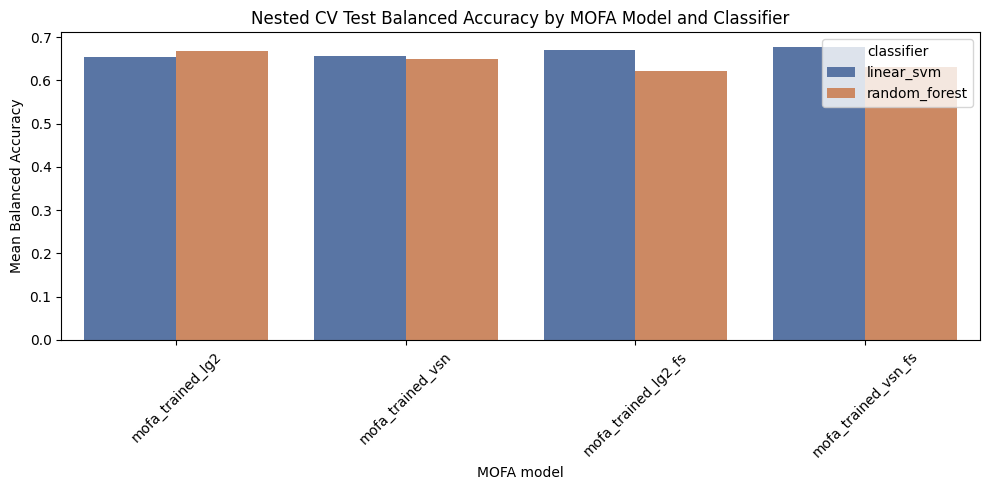

In [23]:
plt.figure(figsize=(10, 5))
plot_df = nested_test_balanced_accuracy.copy()

sns.barplot(
    data=plot_df,
    x="model_name",
    y="mean",
    hue="classifier",
    palette=classifier_palette,
    order=model_order
)

plt.title("Nested CV Test Balanced Accuracy by MOFA Model and Classifier")
plt.xlabel("MOFA model")
plt.ylabel("Mean Balanced Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
nested_model_compare = nested_test_pr_auc.pivot_table(
    index=["classifier", "model_name"],
    columns="metric",
    values="mean"
).reset_index()

nested_model_compare = nested_model_compare.sort_values(
    ["classifier", "pr_auc"],
    ascending=[True, False]
)

display(nested_model_compare)


metric,classifier,model_name,pr_auc
1,linear_svm,mofa_trained_lg2_fs,0.543221
3,linear_svm,mofa_trained_vsn_fs,0.542663
2,linear_svm,mofa_trained_vsn,0.530679
0,linear_svm,mofa_trained_lg2,0.520324
6,random_forest,mofa_trained_vsn,0.500881
4,random_forest,mofa_trained_lg2,0.499946
7,random_forest,mofa_trained_vsn_fs,0.483484
5,random_forest,mofa_trained_lg2_fs,0.454279


In [25]:
nested_test_stability = nested_test_pr_auc[
    nested_test_pr_auc["metric"] == "pr_auc"
].sort_values(["mean", "std"], ascending=[False, True])

display(nested_test_stability[[
    "model_name", "classifier", "mean", "std", "median", "min", "max"
]])


,model_name,classifier,mean,std,median,min,max
149,mofa_trained_lg2_fs,linear_svm,0.543221,0.045666,0.547527,0.458935,0.654961
179,mofa_trained_vsn_fs,linear_svm,0.542663,0.036833,0.543568,0.474730,0.629187
164,mofa_trained_vsn,linear_svm,0.530679,0.039297,0.525365,0.455193,0.590437
134,mofa_trained_lg2,linear_svm,0.520324,0.032609,0.521610,0.460592,0.571640
224,mofa_trained_vsn,random_forest,0.500881,0.026295,0.502841,0.442766,0.558413
194,mofa_trained_lg2,random_forest,0.499946,0.028722,0.504319,0.451623,0.566997
239,mofa_trained_vsn_fs,random_forest,0.483484,0.033875,0.486851,0.413296,0.540313
209,mofa_trained_lg2_fs,random_forest,0.454279,0.038432,0.452492,0.389655,0.559306


Compare train/test split vs nested CV

In [115]:
test_only_df = summary_df[summary_df["scope"] == "test"].copy()

In [116]:
rf_test_df = test_only_df[test_only_df["classifier"] == "random_forest"].copy()

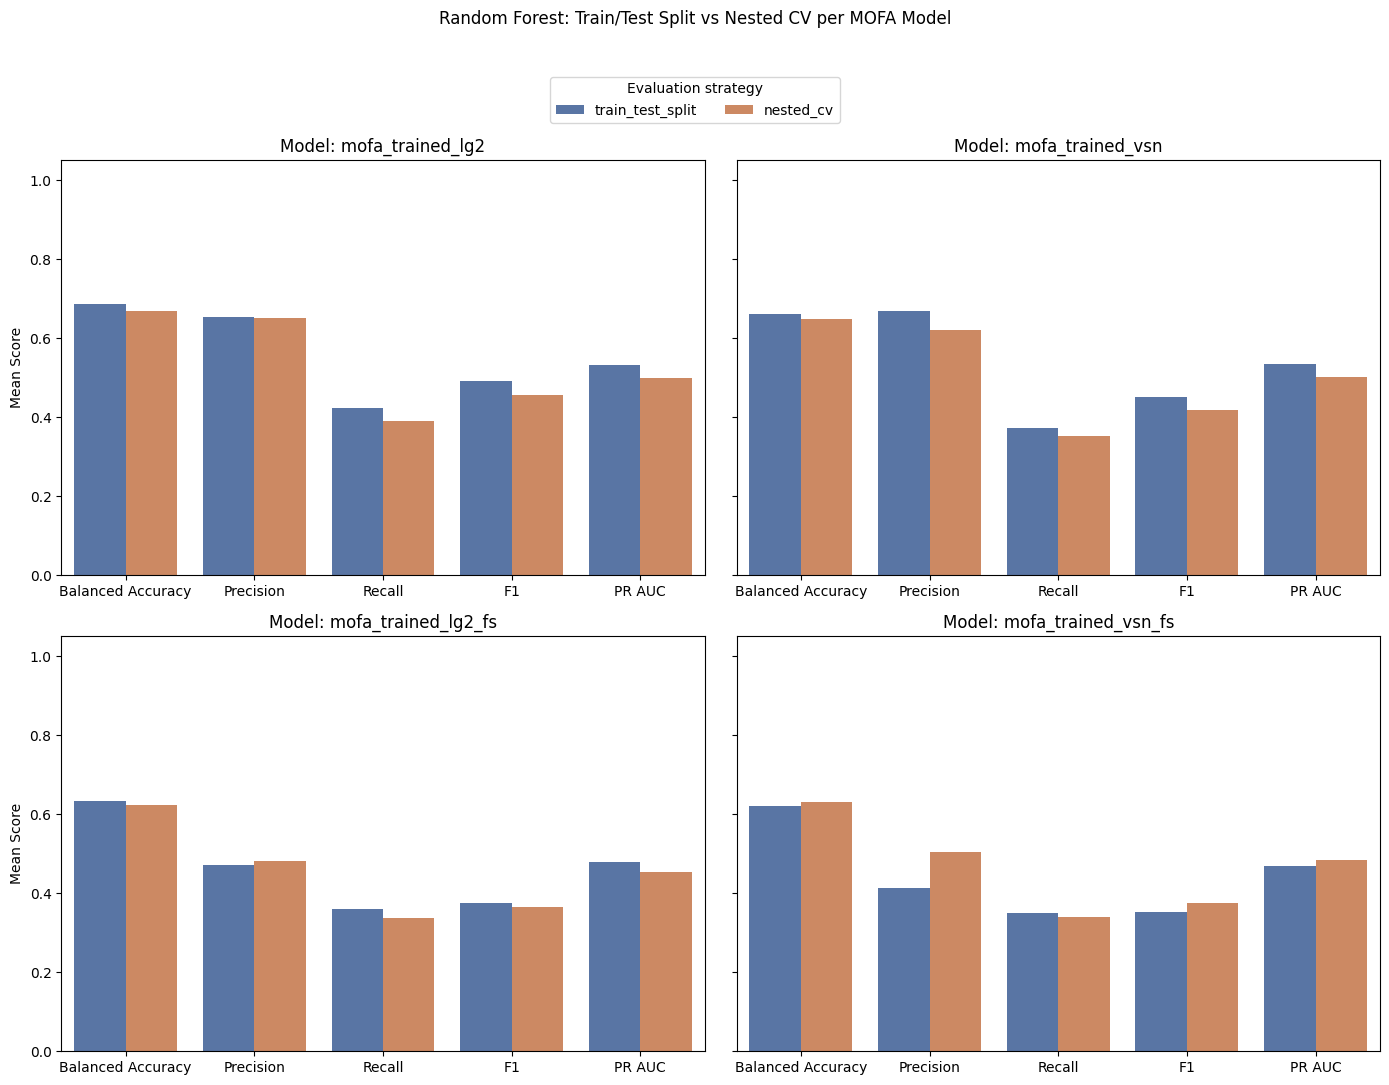

In [ ]:
rf_test_df = test_only_df[
    test_only_df["classifier"] == "random_forest"
].copy()

rf_test_df["metric_label"] = rf_test_df["metric"].map(metric_labels)

metric_order = [
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "PR AUC"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    sub = rf_test_df[rf_test_df["model_name"] == model_name].copy()

    sns.barplot(
        data=sub,
        x="metric_label",
        y="mean",
        hue="evaluation_strategy",
        palette=strategy_palette,
        order=metric_order,
        ax=ax
    )

    ax.set_title(f"Model: {model_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Score")
    ax.set_ylim(0, 1.05)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    ax.get_legend().remove()

fig.legend(
    handles,
    labels,
    title="Evaluation strategy",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle("Random Forest: Train/Test Split vs Nested CV per MOFA Model", y=1.08)
plt.tight_layout()
plt.show()

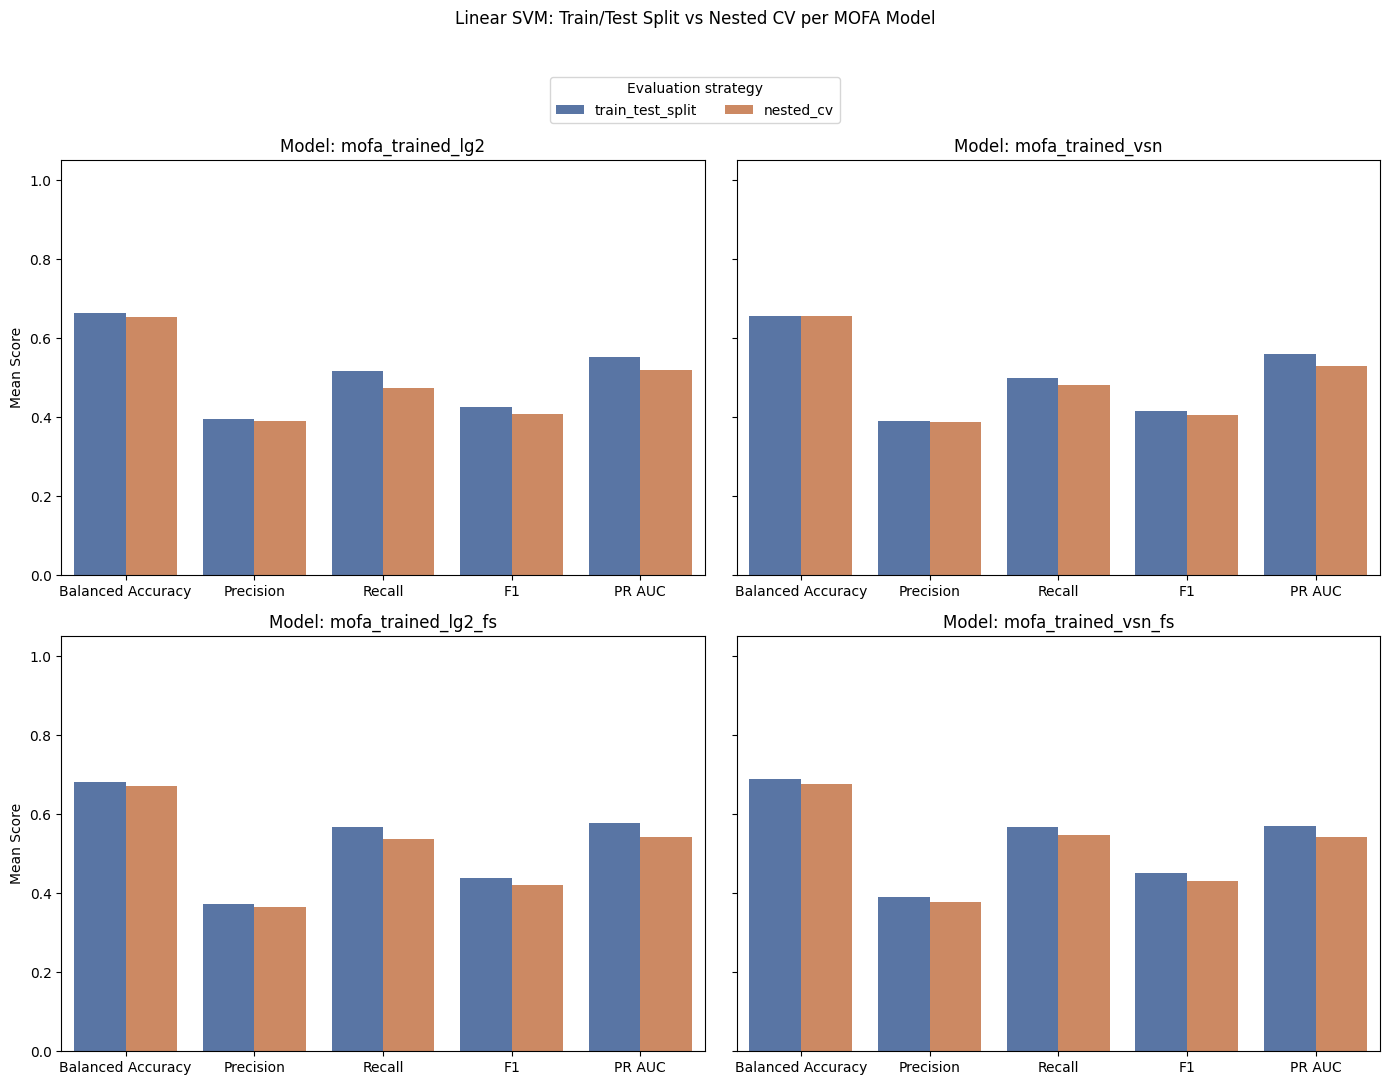

In [122]:
svm_test_df = test_only_df[
    test_only_df["classifier"] == "linear_svm"
].copy()

svm_test_df["metric_label"] = svm_test_df["metric"].map(metric_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    sub = svm_test_df[svm_test_df["model_name"] == model_name].copy()

    sns.barplot(
        data=sub,
        x="metric_label",
        y="mean",
        hue="evaluation_strategy",
        palette=strategy_palette,
        order=metric_order,
        ax=ax
    )

    ax.set_title(f"Model: {model_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Score")
    ax.set_ylim(0, 1.05)

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    ax.get_legend().remove()

fig.legend(
    handles,
    labels,
    title="Evaluation strategy",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle("Linear SVM: Train/Test Split vs Nested CV per MOFA Model", y=1.08)
plt.tight_layout()
plt.show()


train_test_split tem resultados de teste mais otimistas. No entanto não quer dizer que seja melhor

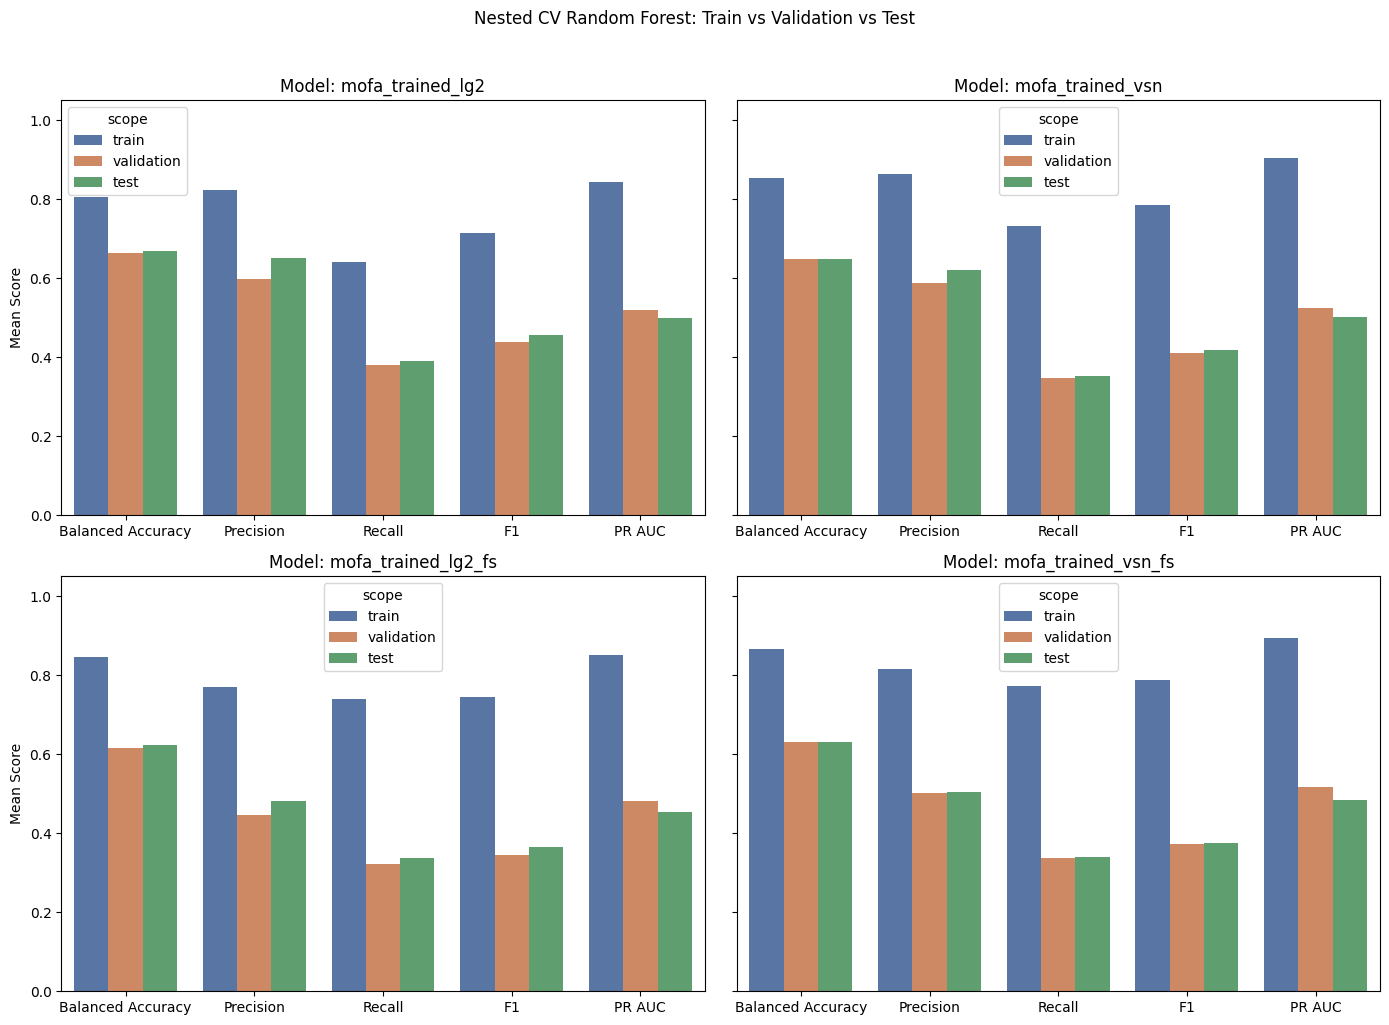

In [125]:
gap_df = summary_df.copy()

plot_df = gap_df[
    (gap_df["evaluation_strategy"] == "nested_cv") &
    (gap_df["classifier"] == "random_forest")
].copy()

plot_df["metric_label"] = plot_df["metric"].map(metric_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    sub = plot_df[plot_df["model_name"] == model_name]

    sns.barplot(
        data=sub,
        x="metric_label",
        y="mean",
        hue="scope",
        ax=ax,
        palette = scope_palette,
    )

    ax.set_title(f"Model: {model_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Score")
    ax.set_ylim(0, 1.05)

plt.suptitle("Nested CV Random Forest: Train vs Validation vs Test", y=1.02)
plt.tight_layout()
plt.show()


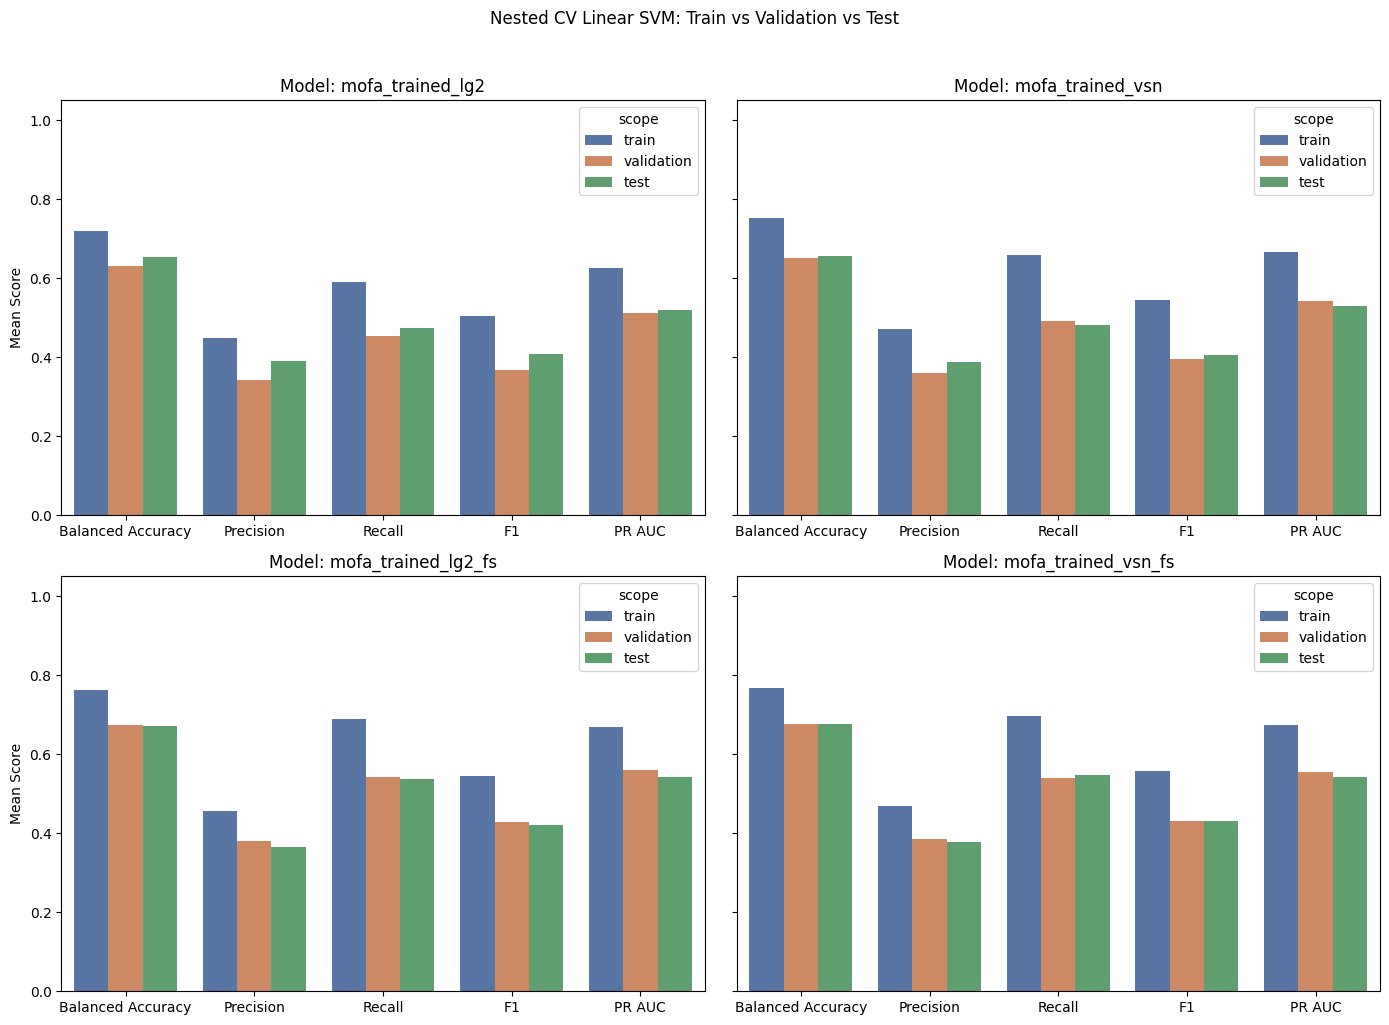

In [127]:
gap_df = summary_df.copy()

plot_df = gap_df[
    (gap_df["evaluation_strategy"] == "nested_cv") &
    (gap_df["classifier"] == "linear_svm")
].copy()

plot_df["metric_label"] = plot_df["metric"].map(metric_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    sub = plot_df[plot_df["model_name"] == model_name]

    sns.barplot(
        data=sub,
        x="metric_label",
        y="mean",
        hue="scope",
        ax=ax,
        palette = scope_palette,
    )

    ax.set_title(f"Model: {model_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Mean Score")
    ax.set_ylim(0, 1.05)

plt.suptitle("Nested CV Linear SVM: Train vs Validation vs Test", y=1.02)
plt.tight_layout()
plt.show()


SVM vs RF

In [137]:
rf_vs_svm_table = nested_test_df.pivot_table(
    index=["model_name", "metric"],
    columns="classifier",
    values=["mean", "std"]
)

display(rf_vs_svm_table)

mean                      std  \
classifier                            linear_svm random_forest linear_svm   
model_name          metric                                                  
mofa_trained_lg2    balanced_accuracy   0.654092      0.667716   0.026058   
                    f1                  0.407993      0.455722   0.040395   
                    pr_auc              0.520324      0.499946   0.032609   
                    precision           0.389426      0.651246   0.059564   
                    recall              0.473333      0.389333   0.039226   
mofa_trained_lg2_fs balanced_accuracy   0.671211      0.622774   0.033011   
                    f1                  0.421767      0.363995   0.044244   
                    pr_auc              0.543221      0.454279   0.045666   
                    precision           0.366261      0.481930   0.053851   
                    recall              0.536667      0.336444   0.057047   
mofa_trained_vsn    balanced_accuracy   0.656475      0.648716   0.024207   
                    f1                  0.406441      0.417975   0.034573   
                    pr_auc              0.530679      0.500881   0.039297   
                    precision           0.388917      0.621630   0.056224   
                    recall              0.481333      0.351556   0.037931   
mofa_trained_vsn_fs balanced_accuracy   0.677498      0.631452   0.026463   
                    f1                  0.431348      0.374099   0.036180   
                    pr_auc              0.542663      0.483484   0.036833   
                    precision           0.377598      0.503358   0.041391   
                    recall              0.546222      0.339778   0.044358   

                                                     
classifier                            random_forest  
model_name          metric                           
mofa_trained_lg2    balanced_accuracy      0.015108  
                    f1                     0.036967  
                    pr_auc                 0.028722  
                    precision              0.084370  
                    recall                 0.020980  
mofa_trained_lg2_fs balanced_accuracy      0.020421  
                    f1                     0.043136  
                    pr_auc                 0.038432  
                    precision              0.089280  
                    recall                 0.045037  
mofa_trained_vsn    balanced_accuracy      0.018157  
                    f1                     0.039919  
                    pr_auc                 0.026295  
                    precision              0.063688  
                    recall                 0.036805  
mofa_trained_vsn_fs balanced_accuracy      0.018490  
                    f1                     0.039323  
                    pr_auc                 0.033875  
                    precision              0.100069  
                    recall                 0.033056

In [138]:
rf_vs_svm_mean = nested_test_df.pivot_table(
    index=["model_name", "metric"],
    columns="classifier",
    values="mean"
).reset_index()

display(rf_vs_svm_mean)

classifier,model_name,metric,linear_svm,random_forest
0,mofa_trained_lg2,balanced_accuracy,0.654092,0.667716
1,mofa_trained_lg2,f1,0.407993,0.455722
2,mofa_trained_lg2,pr_auc,0.520324,0.499946
3,mofa_trained_lg2,precision,0.389426,0.651246
4,mofa_trained_lg2,recall,0.473333,0.389333
5,mofa_trained_lg2_fs,balanced_accuracy,0.671211,0.622774
6,mofa_trained_lg2_fs,f1,0.421767,0.363995
7,mofa_trained_lg2_fs,pr_auc,0.543221,0.454279
8,mofa_trained_lg2_fs,precision,0.366261,0.481930
9,mofa_trained_lg2_fs,recall,0.536667,0.336444


In [141]:
important_metrics = nested_test_df[
    nested_test_df["metric"].isin(["pr_auc", "recall", "f1"])
].copy()

metric_order = ["pr_auc", "recall", "f1"]
important_metrics["metric"] = pd.Categorical(
    important_metrics["metric"],
    categories=metric_order,
    ordered=True
)

important_metrics = important_metrics.sort_values(["model_name", "metric"])

display(
    important_metrics.pivot_table(
        index=["model_name", "metric"],
        columns="classifier",
        values=["mean", "median"]
    )
)


C:\Users\ritam\AppData\Local\Temp\ipykernel_26052\1152801247.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  important_metrics.pivot_table(


mean                   median              
classifier                 linear_svm random_forest linear_svm random_forest
model_name          metric                                                  
mofa_trained_lg2    pr_auc   0.520324      0.499946   0.521610      0.504319
                    recall   0.473333      0.389333   0.480000      0.386667
                    f1       0.407993      0.455722   0.408648      0.447749
mofa_trained_lg2_fs pr_auc   0.543221      0.454279   0.547527      0.452492
                    recall   0.536667      0.336444   0.523333      0.346667
                    f1       0.421767      0.363995   0.420696      0.376180
mofa_trained_vsn    pr_auc   0.530679      0.500881   0.525365      0.502841
                    recall   0.481333      0.351556   0.483333      0.356667
                    f1       0.406441      0.417975   0.403364      0.420808
mofa_trained_vsn_fs pr_auc   0.542663      0.483484   0.543568      0.486851
                    recall   0.546222      0.339778   0.540000      0.346667
                    f1       0.431348      0.374099   0.430860      0.379383

In [26]:
important_metrics = nested_test_df[
    nested_test_df["metric"].isin(["pr_auc", "balanced_accuracy", "recall", "f1"])
].copy()

metric_order = ["pr_auc", "balanced_accuracy", "recall", "f1"]
important_metrics["metric"] = pd.Categorical(
    important_metrics["metric"],
    categories=metric_order,
    ordered=True
)

important_metrics = important_metrics.sort_values(["model_name", "metric"])

display(
    important_metrics.pivot_table(
        index=["model_name", "metric"],
        columns="classifier",
        values=["mean", "median"]
    )
)


C:\Users\ritam\AppData\Local\Temp\ipykernel_16184\260050232.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  important_metrics.pivot_table(


mean                   median  \
classifier                            linear_svm random_forest linear_svm   
model_name          metric                                                  
mofa_trained_lg2    pr_auc              0.520324      0.499946   0.521610   
                    balanced_accuracy   0.654092      0.667716   0.655287   
                    recall              0.473333      0.389333   0.480000   
                    f1                  0.407993      0.455722   0.408648   
mofa_trained_lg2_fs pr_auc              0.543221      0.454279   0.547527   
                    balanced_accuracy   0.671211      0.622774   0.674655   
                    recall              0.536667      0.336444   0.523333   
                    f1                  0.421767      0.363995   0.420696   
mofa_trained_vsn    pr_auc              0.530679      0.500881   0.525365   
                    balanced_accuracy   0.656475      0.648716   0.651609   
                    recall              0.481333      0.351556   0.483333   
                    f1                  0.406441      0.417975   0.403364   
mofa_trained_vsn_fs pr_auc              0.542663      0.483484   0.543568   
                    balanced_accuracy   0.677498      0.631452   0.676437   
                    recall              0.546222      0.339778   0.540000   
                    f1                  0.431348      0.374099   0.430860   

                                                     
classifier                            random_forest  
model_name          metric                           
mofa_trained_lg2    pr_auc                 0.504319  
                    balanced_accuracy      0.666379  
                    recall                 0.386667  
                    f1                     0.447749  
mofa_trained_lg2_fs pr_auc                 0.452492  
                    balanced_accuracy      0.630632  
                    recall                 0.346667  
                    f1                     0.376180  
mofa_trained_vsn    pr_auc                 0.502841  
                    balanced_accuracy      0.652874  
                    recall                 0.356667  
                    f1                     0.420808  
mofa_trained_vsn_fs pr_auc                 0.486851  
                    balanced_accuracy      0.635575  
                    recall                 0.346667  
                    f1                     0.379383